In [1]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [2]:
# >>> train_data.shape
# (404, 13)
# >>> test_data.shape
# (102, 13)

In [3]:
import numpy as np

In [4]:
sample = train_data[np.random.choice(train_data.shape[0], size=2, replace=False)]
sample

array([[2.48017e+01, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.93000e-01,
        5.34900e+00, 9.60000e+01, 1.70280e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.96900e+02, 1.97700e+01],
       [3.73800e-02, 0.00000e+00, 5.19000e+00, 0.00000e+00, 5.15000e-01,
        6.31000e+00, 3.85000e+01, 6.45840e+00, 5.00000e+00, 2.24000e+02,
        2.02000e+01, 3.89400e+02, 6.75000e+00]])

In [5]:
mean = train_data.mean(axis=0)

In [6]:
mean # mean of all columns
# array([3.74511057e+00, 1.14801980e+01, 1.11044307e+01, 6.18811881e-02,
#        5.57355941e-01, 6.26708168e+00, 6.90106436e+01, 3.74027079e+00,
#        9.44059406e+00, 4.05898515e+02, 1.84759901e+01, 3.54783168e+02,
#        1.27408168e+01])

array([3.74511057e+00, 1.14801980e+01, 1.11044307e+01, 6.18811881e-02,
       5.57355941e-01, 6.26708168e+00, 6.90106436e+01, 3.74027079e+00,
       9.44059406e+00, 4.05898515e+02, 1.84759901e+01, 3.54783168e+02,
       1.27408168e+01])

In [7]:
# we want to normalise the data
train_data = train_data - mean
std = train_data.std(axis=0)
train_data = train_data / std
test_data = test_data - mean
test_data = test_data / std
#         x - x̄
# xₙₒᵣₘ = -------
#           σ

In [8]:
from tensorflow import keras
from keras.layers import Dense
def build_model():
    model = keras.Sequential([
        Dense(64, activation="relu", input_shape=(train_data.shape[1],)),
        Dense(64, activation="relu"),
        Dense(1)  # No activation for regression
    ])

    model.compile(
        optimizer="rmsprop",
        loss="mse",      # Mean Squared Error
        metrics=["mae"]  # Mean Absolute Error
    )
    return model

In [9]:
from sklearn.model_selection import KFold
k = 4
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [10]:
# kf.split(train_data) does NOT return data

# It returns indices

# Specifically, for each fold it returns a tuple:

# (train_idx, val_idx)


# Where:

# train_idx → indices for training samples

# val_idx → indices for validation samples

# Example (simplified):

# train_idx = [0, 1, 3, 4, 6]
# val_idx   = [2, 5]

In [11]:
num_epochs = 100
all_mae_histories = []
num_epochs = 100
all_mae_histories = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_data)):
    print("Processing Fold",fold)

    partial_train_data = train_data[train_idx]
    partial_train_targets = train_targets[train_idx]

    val_data = train_data[val_idx]
    val_targets = train_targets[val_idx]

    model = build_model()
    history = model.fit(
        partial_train_data,
        partial_train_targets,
        validation_data=(val_data, val_targets),
        epochs=num_epochs,
        batch_size=16
    )

    all_mae_histories.append(history.history["val_mae"])


Processing Fold 0
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 624.7800 - mae: 22.8566 - val_loss: 408.9893 - val_mae: 18.5404
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 435.5319 - mae: 19.0518 - val_loss: 296.0843 - val_mae: 15.4682
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 304.3511 - mae: 15.5635 - val_loss: 181.0250 - val_mae: 11.6428
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 166.6762 - mae: 10.7186 - val_loss: 103.1212 - val_mae: 8.3670
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 93.1810 - mae: 7.2113 - val_loss: 63.9753 - val_mae: 6.1968
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 63.2599 - mae: 5.6807 - val_loss: 46.8764 - val_mae: 5.0596
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 38.4091 - mae: 4.3297 - val_loss: 37.4441 - val_mae: 4.3710
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 39.9031 - mae: 4.3079 - val_loss: 33.1631 - val_mae: 4.0274
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

In [17]:
average_mae_history = np.mean(all_mae_histories, axis=0)

In [18]:
average_mae_history

array([19.43912458, 15.89971972, 11.77851319,  8.13874471,  5.84816623,
        4.66118491,  4.04288185,  3.66676164,  3.48707688,  3.34524703,
        3.23731548,  3.1611827 ,  3.05131525,  2.95637977,  2.94741809,
        2.87194228,  2.82919472,  2.86532736,  2.73955607,  2.69420761,
        2.66057819,  2.70713705,  2.63072717,  2.62991929,  2.62365144,
        2.62601584,  2.58692396,  2.65245771,  2.56264126,  2.55822694,
        2.53559685,  2.53676677,  2.57853591,  2.55745155,  2.5963431 ,
        2.56234026,  2.56936252,  2.50059664,  2.5397045 ,  2.58824593,
        2.5001694 ,  2.59815735,  2.53008175,  2.55936331,  2.49509686,
        2.51451397,  2.54690903,  2.54500729,  2.45633191,  2.5046432 ,
        2.50467438,  2.51021105,  2.50670749,  2.49344569,  2.51065183,
        2.52222812,  2.52340937,  2.49214911,  2.47646183,  2.50149602,
        2.51043814,  2.52180505,  2.52613205,  2.46704012,  2.49664056,
        2.51923871,  2.57374114,  2.47703034,  2.47722691,  2.52

In [21]:
# Train final model on full training data
# # --------------------------------------------------
model = build_model()
model.fit(
    train_data,
    train_targets,
    epochs=80,
    batch_size=16
)

Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 502.8564 - mae: 20.5996   
Epoch 2/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 369.8863 - mae: 17.0932 
Epoch 3/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 186.7191 - mae: 10.9819 
Epoch 4/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 80.5124 - mae: 6.8537
Epoch 5/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 51.8664 - mae: 4.9941 
Epoch 6/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.0794 - mae: 4.0411 
Epoch 7/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.9294 - mae: 3.6282 
Epoch 8/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 23.6178 - mae: 3.2410 
Epoch 9/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15.2311 - mae: 2.8060
Epoch 10/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17.3196 - mae: 2.9517 
Epoch 11/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.4613 - mae: 2.7624
Epoch 12/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.6748 - mae: 2.5229
Epoch 13/80
26/26 ━━━

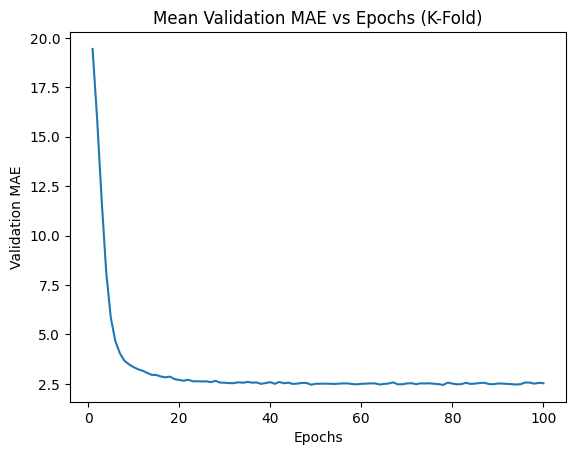

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(average_mae_history) + 1)

plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.title("Mean Validation MAE vs Epochs (K-Fold)")
plt.show()

In [23]:
model.evaluate(test_data, test_targets)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 12.8327 - mae: 2.3655


[18.08027458190918, 2.5732524394989014]